In [12]:
%load_ext autoreload
%autoreload 2
from scripts.utils import *
from scripts.gaussianclassifiers import *
from scripts.dcf import *
from scripts.logisticreg import *
from scripts.SVM import *
from scripts.GMM import *
from scripts.plots import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 📘 Theory & Key Functions
**Theoretical Recall:** Gaussian Mixture Models (GMM) represent complex probability densities as a weighted sum of $K$ simple Gaussian components. They are highly effective for modeling multimodal distributions.
Training relies on the **Expectation-Maximization (EM)** algorithm. To initialize EM, the **LBG algorithm** is used: it starts with a single Gaussian, splits it by perturbing the mean, runs EM, and repeats until $K$ components are reached.

**Key Functions (from `GMM.py`):**
- `LBG_constrained(X, K, psi)`: Orchestrates the component-splitting process and runs EM at each step. It enforces a lower bound constraint ($\psi$) on the eigenvalues of the covariance matrices to prevent singularities (collapsing variances).
- `logpdf_GMM(X, gmm)`: Computes the marginal log-density of samples under the learned GMM by computing the LogSumExp of the individual component densities.

 See [GMM.py](../scripts/GMM.py) for the implementation.

In [8]:
D,L,labels=init_dataset()
(DTR, LTR), (DVAL, LVAL) = split_db_2to1(D, L)


In [10]:
n_components = [1, 2, 4, 8, 16,32]

# Separazione del dataset di training per classe
DTR0 = DTR[:, LTR == 0]
DTR1 = DTR[:, LTR == 1]
pi_T=0.5
for i in n_components:
    print(f"---------------------------GMM Components: {i}--------------------------------")

    # Addestramento di un GMM SEPARATO per ogni singola classe
    gmm0 = LBG_constrained(DTR0, threshold=1e-6, target_components=i, alpha=0.1, psi=0.01)
    gmm1 = LBG_constrained(DTR1, threshold=1e-6, target_components=i, alpha=0.1, psi=0.01)
    # Calcolo delle log-densità marginali sul validation set (ignoriamo la matrice S)
    _, logdens0 = logpdf_GMM(DVAL, gmm0)
    _, logdens1 = logpdf_GMM(DVAL, gmm1)


    llr = logdens1 - logdens0

    # Predizione: se LLR > 0 vince la classe 1, altrimenti classe 0
    predictions = np.where(llr > 0, 1, 0)

    # Calcolo dell'accuratezza e dell'Error Rate
    acc = np.where(predictions == LVAL, 1, 0).mean()
    err = 1 - acc

    # Stampa formattata per maggiore chiarezza
    print(f"Error rate: {err * 100:.2f}%\n")
    min_dcf=compute_min_dcf(llr,LVAL,pi_T,1,1)
    predictions_bayes=get_bayes_decision(llr,pi_T,1,1)
    act_dcf=DCF_norm(predictions_bayes,LVAL,pi_T,1,1)
    print(f"DCF min: {min_dcf}")
    print(f"Actual DCF:{act_dcf}\n")

---------------------------GMM Components: 1--------------------------------
Error rate: 7.00%

DCF min: 0.13016833077316947
Actual DCF:0.13992895545314898

---------------------------GMM Components: 2--------------------------------
Error rate: 5.35%

DCF min: 0.10616679467485919
Actual DCF:0.10715885816692268

---------------------------GMM Components: 4--------------------------------
Error rate: 4.35%

DCF min: 0.08282130056323606
Actual DCF:0.0869815668202765

---------------------------GMM Components: 8--------------------------------
Error rate: 3.15%

DCF min: 0.06000384024577573
Actual DCF:0.06294802867383513

---------------------------GMM Components: 16--------------------------------
Error rate: 3.05%

DCF min: 0.060947900665642596
Actual DCF:0.060947900665642596

---------------------------GMM Components: 32--------------------------------
Error rate: 4.35%

DCF min: 0.08515745007680492
Actual DCF:0.08696556579621095



Let's save the best result.

In [12]:
gmm0 = LBG_constrained(DTR0, threshold=1e-6, target_components=8, alpha=0.1, psi=0.01)
gmm1 = LBG_constrained(DTR1, threshold=1e-6, target_components=8, alpha=0.1, psi=0.01)
_, logdens0 = logpdf_GMM(DVAL, gmm0)   
_, logdens1 = logpdf_GMM(DVAL, gmm1)
llr = logdens1 - logdens0
np.save('llr/score_gmm_best.npy', llr)

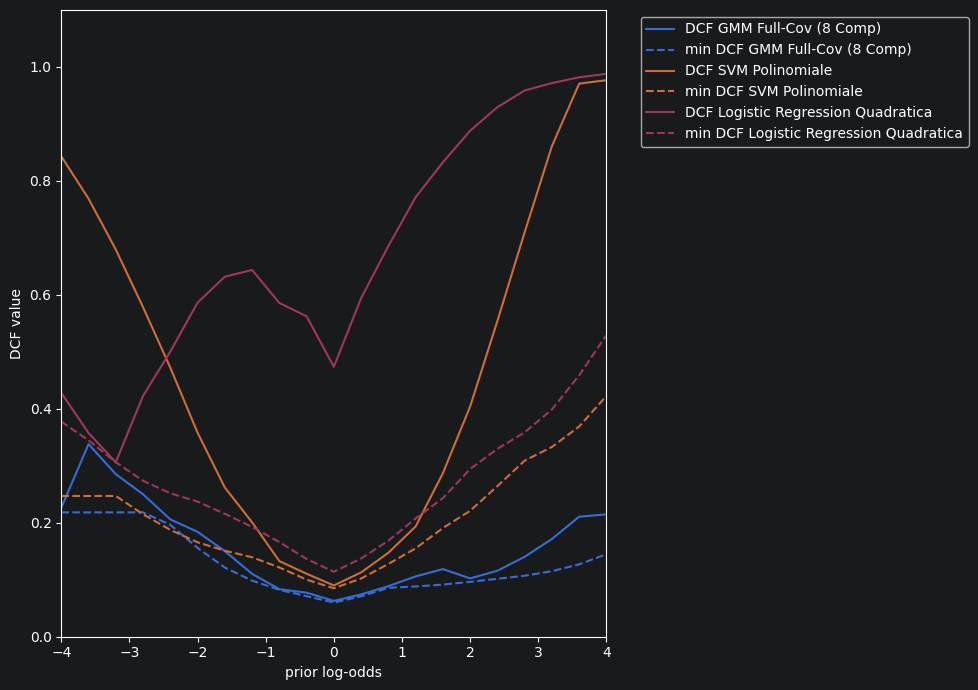

In [13]:
import numpy as np

llr_gmm_best=np.load('llr/score_gmm_best.npy')
score_lr_best = np.load('llr/score_lr_best.npy')
score_svm_best = np.load('llr/score_svm_best.npy')


llr_migliori = {
    'GMM Full-Cov (8 Comp)': llr_gmm_best,  
    'SVM Polinomiale': score_svm_best,
    'Logistic Regression Quadratica': score_lr_best
}

plot_bayes_error(llr_migliori, LVAL)